<a href="https://colab.research.google.com/github/Nniichha/229352-StatisticalLearning/blob/main/660510739_Lab06_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #6

## Support Vector Machines (SVM)

[SVM module documentation](https://scikit-learn.org/stable/modules/svm.html#svm)

[LinearSVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

[SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC  # fast but only linear
from sklearn.svm import SVC  # slower but can do kernels

In [2]:
# Load the iris data
iris = datasets.load_iris()
X = iris.data[:, 2:]
y = iris.target

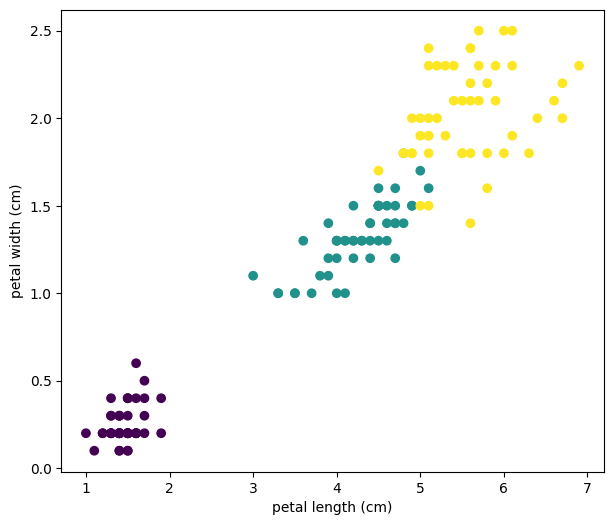

In [3]:
# Plot the data
plt.figure(figsize=(7,6))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()

#### In this problem, you'll use support vector machines to classify the Iris data

#### The following function helps you plot the decision boundary.

In [4]:
# Plot the decision boundaries
def plot_decision_boundary(clf, X, y):
    h = 0.005  # Boundary lines' resolution
    x_min, x_max = X[:,0].min() - 10*h, X[:,0].max() + 10*h
    y_min, y_max = X[:,1].min() - 10*h, X[:,1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, alpha=0.25)  # Background
    plt.contour(xx, yy, Z, colors='k', linewidths=0.2)  # Boundary lines
    plt.scatter(X[:,0], X[:,1], c=y);  # Data points
    plt.xlabel(iris.feature_names[2])
    plt.ylabel(iris.feature_names[3])

#### Exercise 1. Split the data into training set and test set.

In [7]:
#TODO
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)


(105, 2)
(45, 2)


#### Exercise 2. Learn a linear SVM classifier using sklearn.svm.LinearSVC. You will need to set `loss='hinge'`.

#### Try different values of the tradeoff parameter: `C = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `C` on the decision boundary?

<Figure size 640x480 with 0 Axes>

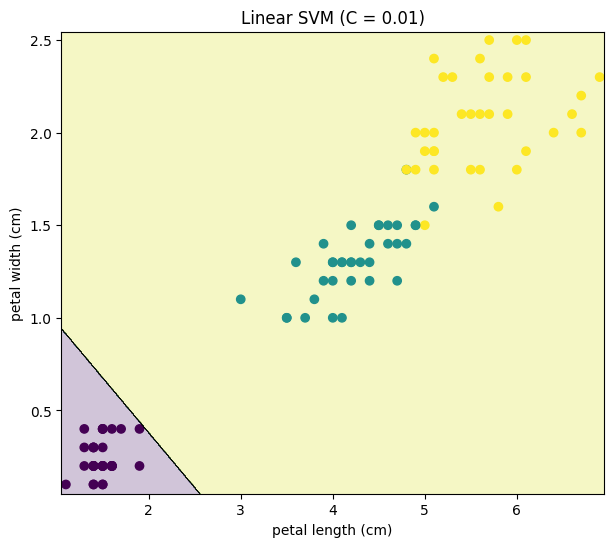

<Figure size 640x480 with 0 Axes>

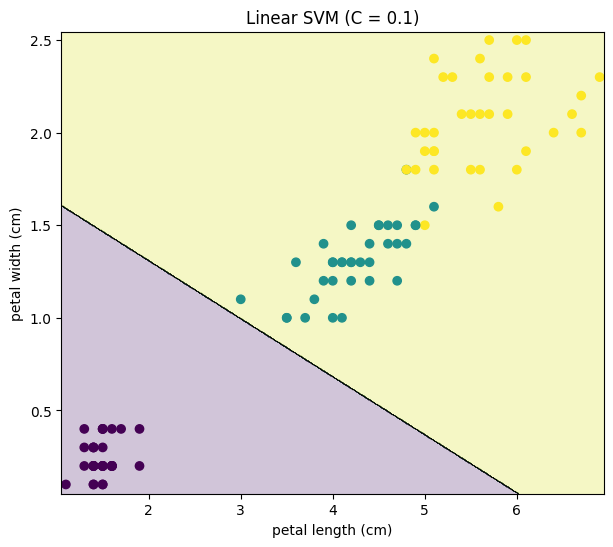

<Figure size 640x480 with 0 Axes>

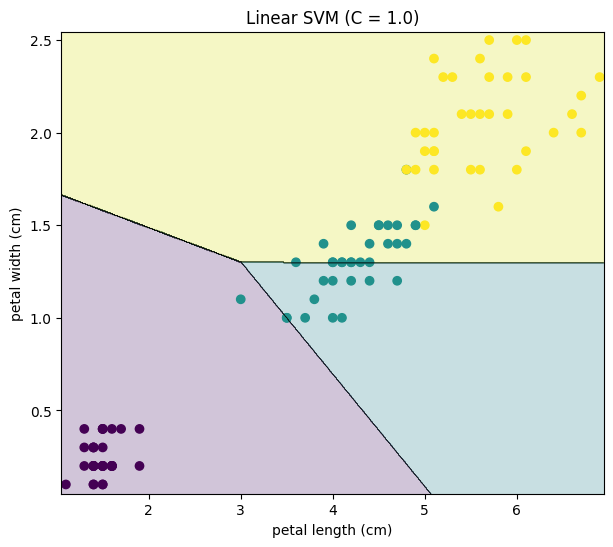

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

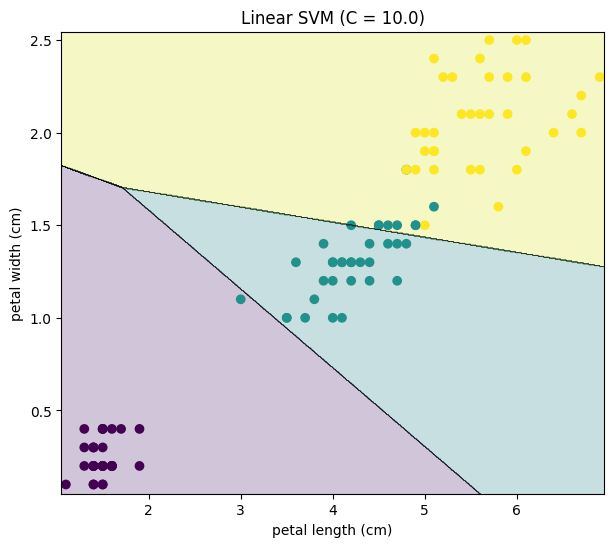

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

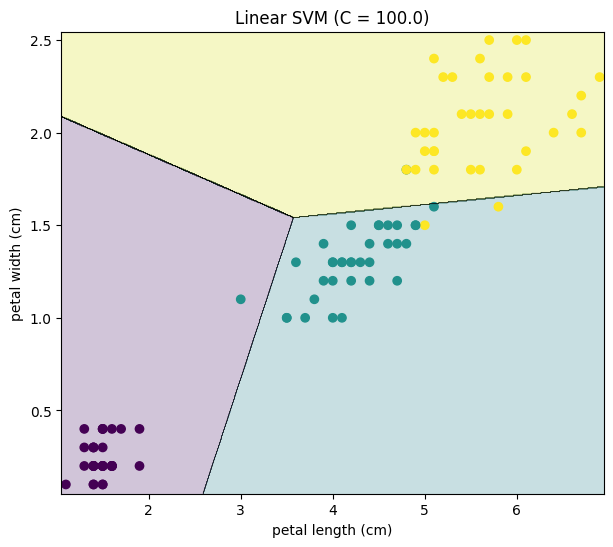

In [8]:
#TODO
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

for C in C_values:
    clf = LinearSVC(
        C=C,
        loss='hinge',
        max_iter=100000,
        random_state=42
    )
    clf.fit(X_train, y_train)

    plt.figure()
    plot_decision_boundary(clf, X_train, y_train)
    plt.title(f"Linear SVM (C = {C})")
    plt.show()


#### Exercise 3. Pick a value of `C` that you like. Then report the test error.

In [20]:

from sklearn.metrics import accuracy_score

clf = LinearSVC(
    C=1.0,
    loss='hinge',
    max_iter=100000,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_error = 1 - test_accuracy




In [21]:
print(test_accuracy)

0.6888888888888889


In [22]:
print(test_error)

0.3111111111111111


#### Exercise 4. Now try kernel SVM with a quadratic kernel. You can do this with sklearn.svm.SVC, setting `kernel='rbf'` and `C = 1.0`.

#### Try different values of the tradeoff parameter: `gamma = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `gamma` on the decision boundary?

<Figure size 640x480 with 0 Axes>

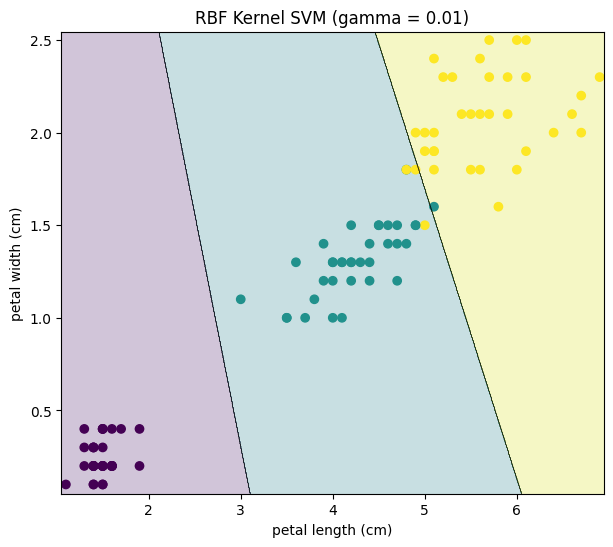

<Figure size 640x480 with 0 Axes>

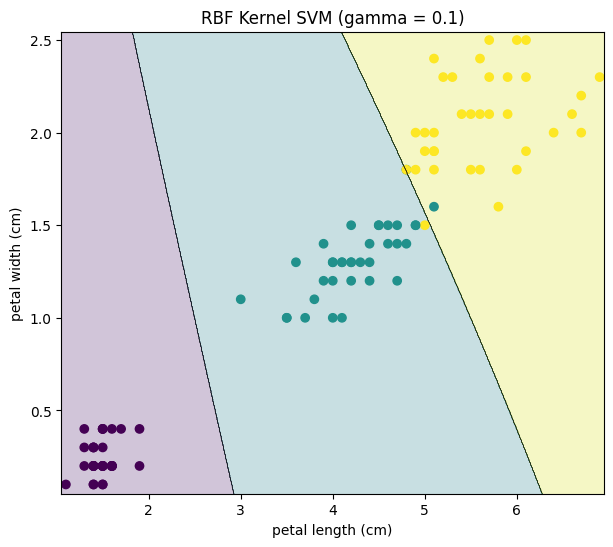

<Figure size 640x480 with 0 Axes>

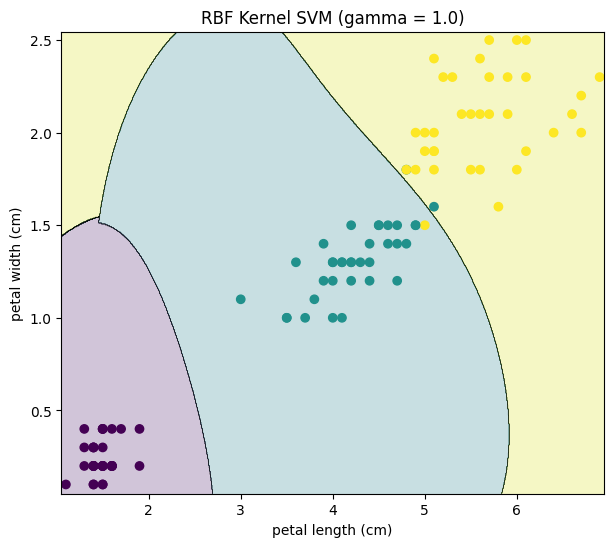

<Figure size 640x480 with 0 Axes>

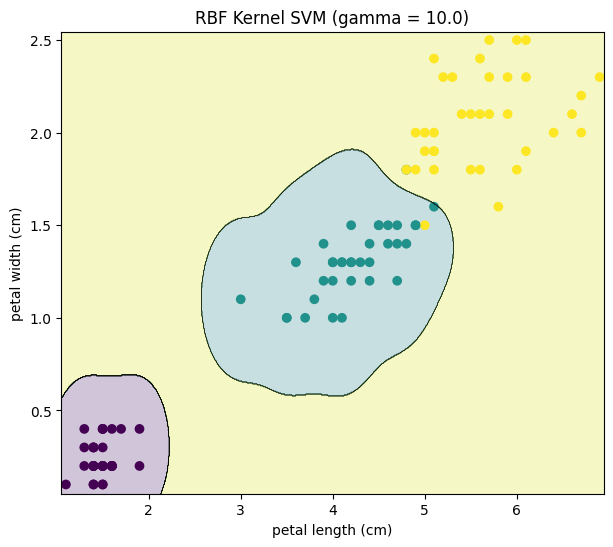

<Figure size 640x480 with 0 Axes>

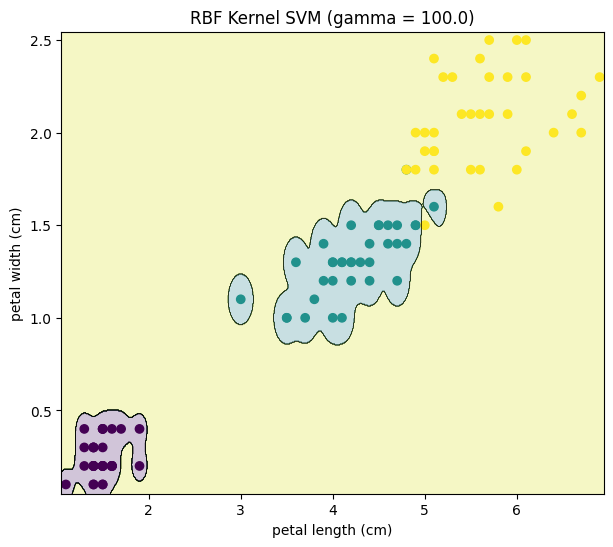

In [12]:
#TODO
gamma_values = [0.01, 0.1, 1.0, 10.0, 100.0]

for gamma in gamma_values:
    clf = SVC(
        kernel='rbf',
        C=1.0,
        gamma=gamma,
        max_iter=100000
    )
    clf.fit(X_train, y_train)

    plt.figure()
    plot_decision_boundary(clf, X_train, y_train)
    plt.title(f"RBF Kernel SVM (gamma = {gamma})")
    plt.show()


#### Exercise 5. Pick a value of `gamma` that you like. Then report the test error and the number of support vectors.

In [17]:
#TODO
clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma=0.1,
    max_iter=100000
)

clf.fit(X_train, y_train)

# prediction on test set
y_pred = clf.predict(X_test)

# test error
test_accuracy = accuracy_score(y_test, y_pred)
test_error = 1 - test_accuracy

# number of support vectors
num_support_vectors = clf.n_support_.sum()




In [18]:
print(test_error)

0.0444444444444444


In [19]:
print(num_support_vectors)

37


#### Exercise 6. Between Linear SVM and Kernel SVM, which model would you prefer to use for classification of Iris data?
1. Explain using test accuracy
2. Explaing using decision boundary plot

ระหว่าง Linear SVM และ Kernel SVM โมเดลที่เหมาะสมกว่าสำหรับการจำแนกข้อมูล Iris คือ Kernel SVM (RBF kernel)

1. test accuracy:
จากผลการทดลองพบว่า Kernel SVM ให้ค่า test accuracy สูงกว่า Linear SVM แสดงให้เห็นว่า Kernel SVM สามารถจำแนกข้อมูลที่ไม่เคยเห็นมาก่อนได้ดีกว่า ในขณะที่ Linear SVM ใช้เส้นแบ่งแบบเส้นตรง ซึ่งอาจไม่เพียงพอในการแยกข้อมูล Iris ที่มีความซับซ้อน

2. decision boundary:
เมื่อพิจารณาจากกราฟ decision boundary จะเห็นว่า Linear SVM ให้เส้นแบ่งเป็นเส้นตรง ทำให้ยังมีบางจุดที่แยกคลาสได้ไม่ชัดเจน ส่วน Kernel SVM ให้เส้นแบ่งที่โค้งและยืดหยุ่นมากกว่า จึงสามารถแยกกลุ่มข้อมูลได้ชัดเจนและสอดคล้องกับการกระจายของข้อมูลมากกว่า

In [ ]:
#TODO